Install & import libraries

In [12]:
%pip install kagglehub[pandas-datasets] --quiet

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
sns.set(style="whitegrid")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Load the dataset from Kaggle

In [13]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

# Load CSV file
csv_path = os.path.join(path, "creditcard.csv")

df = pd.read_csv(csv_path)

# Display dataset information
print("Dataset shape:", df.shape)

Dataset shape: (284807, 31)


Exploratory Data Analysis (EDA)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Missing values & duplicates

In [15]:
print("Missing values per column:\n", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
 0
Duplicate rows: 1081


In [16]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Class balance (the most important check for fraud data)

Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


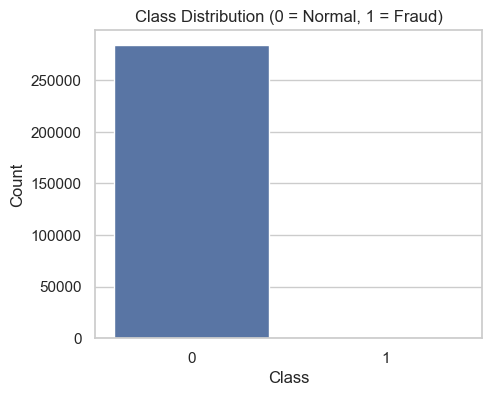

In [17]:
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"\nFraud percentage: {class_counts[1] / len(df) * 100:.4f}%")

plt.figure(figsize=(5,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0 = Normal, 1 = Fraud)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

Distribution of Amount and Time

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))

sns.histplot(df['Amount'], bins=50, ax=ax[0], kde=True)
ax[0].set_title('Distribution of Transaction Amount')

sns.histplot(df['Time'], bins=50, ax=ax[1], kde=True)
ax[1].set_title('Distribution of Time (seconds since first transaction)')

plt.tight_layout()
plt.show()

Amount distribution: fraud vs normal

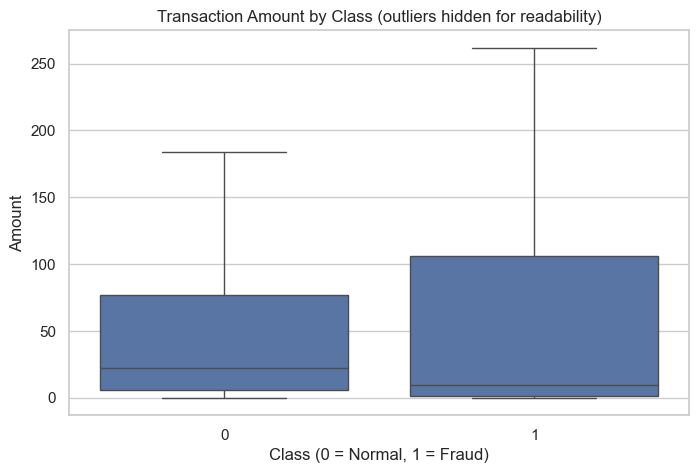

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df, showfliers=False)
plt.title('Transaction Amount by Class (outliers hidden for readability)')
plt.xlabel('Class (0 = Normal, 1 = Fraud)')
plt.ylabel('Amount')
plt.show()

Correlation heatmap

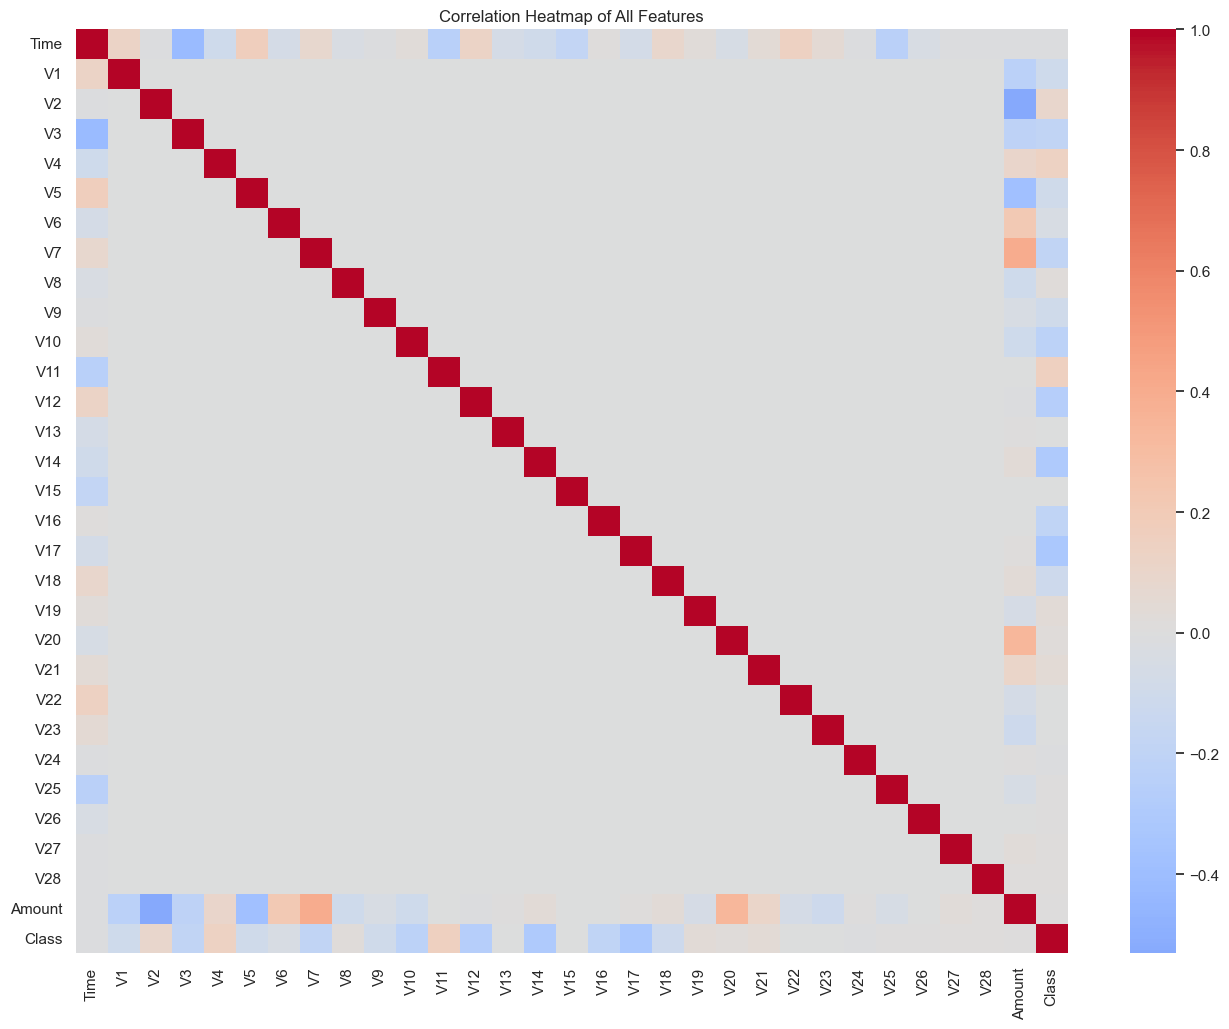

In [ ]:
plt.figure(figsize=(16,12))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of All Features')
plt.show()

Top features correlated with fraud

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
Name: Class, dtype: float64


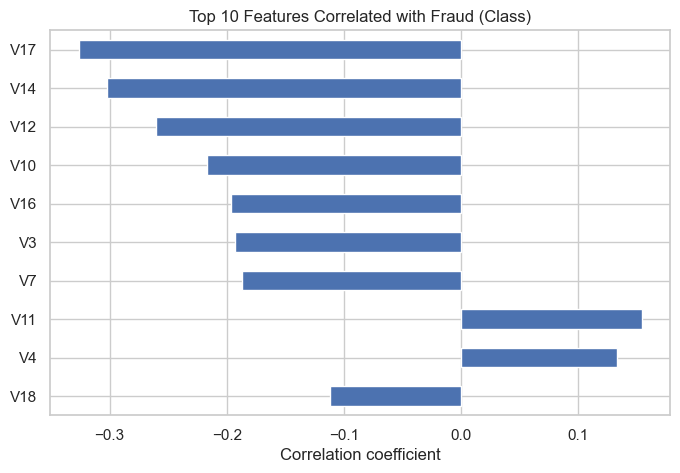

In [ ]:
fraud_corr = corr['Class'].drop('Class').sort_values(key=abs, ascending=False)
print(fraud_corr.head(10))

plt.figure(figsize=(8,5))
fraud_corr.head(10).plot(kind='barh')
plt.title('Top 10 Features Correlated with Fraud (Class)')
plt.xlabel('Correlation coefficient')
plt.gca().invert_yaxis()
plt.show()

Data Cleaning

In [ ]:
#Drop duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows")

Removed 1081 duplicate rows


Train / Validation / Test Split

In [ ]:
# Split the data
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

# First split: train+validation vs test (80/20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Second split: train vs validation (60/20/20 overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape, "Fraud rate:", y_train.mean())
print("Val:", X_val.shape, "Fraud rate:", y_val.mean())
print("Test:", X_test.shape, "Fraud rate:", y_test.mean())

Train: (170235, 30) Fraud rate: 0.0016682820806532147
Val: (56745, 30) Fraud rate: 0.0016565336152965019
Test: (56746, 30) Fraud rate: 0.0016741268107003137
